**Author:** [Nimota Ibrahim](https://github.com/NimotaPro/NimotaPro)  

**Table of Contents**
1. Introduction 
2. Dataset
3. Features with High Missing Values
4. Train-Validation Split
5.  Feature Engineering and Data Cleaning
6.  Selecting Categorical & Numeric Columns
7.  Selecting Categorical Columns
8.  Selecting Numeric Columns
9.  Define the Modeling Feature Blueprint
10. Import the Test Dataset
11. Unified Feature Engineering & Data Cleaning Function
12. Model & Pipeline
13. Model Performance: Mean Absolute Error
14. Feature Evolution: Visual Insights
15. A Comparative Study of Irreducible Error
16. Recommendation
17. Final Conclusion






# 1. Introduction

This project is a follow-up study to an earlier house price prediction model, building directly on the baseline approach developed in a previous **XGBoost-based pipeline** project. **[link to baseline project here](https://github.com/NimotaPro/House-Price-Prediction/blob/main/house_price_prediction_project.ipynb)**. The objective of this extension is not to replace the original model, but to **investigate the impact of additional feature engineering** on model behavior, stability, and interpretability.

By introducing aggregated and transformed features, this study examines how changes in feature representation influence prediction logic and error patterns. The results highlight important trade-offs between model stability, interpretability, and predictive accuracy, offering deeper insight into how feature engineering affects real-world machine learning models.

# 2. Datasets


The datasets used in this project (train.csv and test.csv), part of the Ames Housing dataset, were obtained from **Kaggle** and consist of residential property sales records. Each row represents a single property, with columns capturing structural attributes and sale prices. A full description of all variables is provided in the accompanying data description file (data_description.txt), originally prepared by Dean De Cock and lightly edited to match the column names used in this project. The full datasets and accompanying documentation are publicly available via the Kaggle repository link **[here](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data)**.


The datasets contain a rich mix of numerical, nominal, and ordinal categorical variables, making them well-suited for supervised regression modeling with tree-based methods such as XGBoost.

**Note on source**: The original dataset comes from the Kaggle competition "House Prices: Advanced Regression Techniques." Accessing it directly from Kaggle requires joining the competition. 

To ensure reproducibility without requiring Kaggle account access, the training and test CSV files (**renamed ml_housing_train.csv and ml_housing_test.csv**) as well as the accompanying data description text file are included directly in this GitHub repository alongside the notebook.


In [5]:
# Load and preview data

import pandas as pd


df = pd.read_csv('ml_housing_train.csv', index_col='Id')
df.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### 2.1 Inspect Dataset 

In [8]:
# Inspect the structure of the dataset using .info()
# Total rows: 1,460; total columns: 80
# Column types: 43 object/text, 34 integer, 3 float
# Some columns contain missing values (e.g., 'Alley' has only 91 non-null entries out of 1,460)

# Missing values will be handled during preprocessing:
# - Columns with a high percentage of missing values may be dropped
# - Other missing values will be imputed using assigned placeholders 



df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

### 2.2 Feature-Target Separation

In [11]:
# Define the target variable (SalePrice) 

y = df.SalePrice


In [13]:
# Select feature columns/ drop the target column 


df.drop(['SalePrice'], axis=1, inplace=True)


In [15]:
# Confirm that the target column has been dropped (79 columns remain)


df.shape


(1460, 79)

# 3. Features with High Missing Values

* Feature columns with at **least 90% missing values** are  are **excluded** to reduce noise and improve model reliability

* The 3 columns are **PoolQC, MiscFeature, and Alley**  

 


In [18]:
# Identify feature columns with more than >=90% missing values
# First, compute the percentage of missing values for each column


missing_percent = df.isnull().mean() * 100
print('Columns with high missing values:\n')
print(missing_percent.sort_values(ascending=False))


Columns with high missing values:

PoolQC           99.520548
MiscFeature      96.301370
Alley            93.767123
Fence            80.753425
MasVnrType       59.726027
                   ...    
Heating           0.000000
MSZoning          0.000000
CentralAir        0.000000
1stFlrSF          0.000000
SaleCondition     0.000000
Length: 79, dtype: float64


In [20]:
# Display columns with high missing values (>=90%) 
# Total columns with high missing values: 3 (e.g., PoolQC has >99% missing)
# These extremely sparse columns will be dropped 




high_missing = pd.DataFrame(
    [(feature, percent_value) for feature, percent_value in missing_percent.items() if percent_value >= 90],
    columns=['SparseFeature', 'MissingPercent']
)

print(high_missing)
print('\nTotal number of columns with high missing values:', len(high_missing))


  SparseFeature  MissingPercent
0         Alley       93.767123
1        PoolQC       99.520548
2   MiscFeature       96.301370

Total number of columns with high missing values: 3


In [22]:
# Drop columns with high missing values (Alley, PoolQC, MiscFeature) 


cols_to_drop = ['Alley', 'PoolQC', 'MiscFeature']
X = df.drop(columns = cols_to_drop)



In [24]:
# Verify dataset structure after dropping high-missing features (76 features)


X.shape


(1460, 76)

# 4. Train-Validation Split


* Following the train-validation split, all **data cleaning and manipulation procedures** are applied **exclusively to the training set**

* The resulting transformations are formalised into a single **reusable function** and applied identically to the **validation and test sets**

In [27]:

# We split the data 80/20 to ensure we have a robust validation set for testing the model's generalization on unseen data

# X_train_full: input features for model training
# X_valid_full: input features for validation
# y_train: target values for model training
# y_valid: target values for validation (these are the values the model will try to predict)

from sklearn.model_selection import train_test_split

X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2, random_state=0)


# 5. Feature Engineering and Data Cleaning

The preprocessing steps on the train set include: 
* (i) conversion of structural missing values to 0 for numerical features and 'None' for categorical features
* (ii) type coercion of MSSubClass and MoSold to string to enforce categorical treatment
* (iii) replacement of Neighborhood and Exterior2nd with engineered features (Neighborhood_enc and Has2ndExterior)
* (iv) creation of four additional engineered features, yielding a total of **six newly introduced features** after accounting for feature replacement
* Component features (e.g., GrLivArea and TotalBsmtSF) aree retained alongside the engineered TotalSF to capture both overall scale and the spatial       distribution of living area, which may influence market value

#### Newly Created Columns

* **Total Square Footage (TotalSF)**: Sum of Above Grade Living Area (GrLivArea) and Basement (TotalBsmtSF) to capture the full structural footprint.
* **Total Bathrooms (TotalBath)**: Combines full and half baths (half-baths = 0.5), reflecting typical buyer valuation.
* **House Age (HouseAge)**: Difference between YrSold and YearBuilt, indicating the level of depreciation and maintenance state.
* **Remodel Status (IsRemodeled)**: Binary flag identifying homes remodeled after construction, capturing the value premium from updated interiors and      structures.
* **Neighborhood Encoded (Neighborhood_enc)**: Replaces each neighborhood with the **average SalePrice** in that area, converting a categorical             variable into a numeric feature reflecting local market value.
* **Has Second Exterior (Has2ndExterior)**: Binary feature indicating whether the home has different materials on the front and back exteriors


In [30]:
# Feature Engineering

# 1. House Age
# ------------------------------
# Store median years to fill missing values consistently across Train, Valid, and Test sets
median_yr_sold = X_train_full['YrSold'].median()
median_yr_built = X_train_full['YearBuilt'].median()

# Fill missing years using the medians
X_train_full['YrSold'] = X_train_full['YrSold'].fillna(median_yr_sold)
X_train_full['YearBuilt'] = X_train_full['YearBuilt'].fillna(median_yr_built)

# Compute the age of the house 
X_train_full['HouseAge'] = X_train_full['YrSold'] - X_train_full['YearBuilt']

# Ensure HouseAge is non-negative to handle data entry errors or pre-construction sales (where YrSold may precede YearBuilt)
X_train_full['HouseAge'] = X_train_full['HouseAge'].apply(lambda x: x if x > 0 else 0)


# 2. Total Square Footage
# ------------------------------
# Compute total livable area by summing above-grade (GrLivArea) and basement (TotalBsmtSF) areas
# Missing values are treated as 0
X_train_full['TotalSF'] = X_train_full['GrLivArea'].fillna(0) + X_train_full['TotalBsmtSF'].fillna(0)


# 3. Total Bathrooms
# ------------------------------
# Fill missing values in bathroom columns with 0
bath_cols = ['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
X_train_full[bath_cols] = X_train_full[bath_cols].fillna(0)

# Compute total bathrooms, weighting half baths as 0.5, summing both above-grade and basement
X_train_full['TotalBath'] = (
    X_train_full['FullBath'] + 
    (0.5 * X_train_full['HalfBath']) + 
    X_train_full['BsmtFullBath'] + 
    (0.5 * X_train_full['BsmtHalfBath'])
)


# 4. Remodeled Feature
# ------------------------------
# Create binary feature indicating whether the house has been remodeled
# 1 if YearRemodAdd != YearBuilt, else 0
X_train_full['IsRemodeled'] = (X_train_full['YearRemodAdd'] != X_train_full['YearBuilt']).astype(int)


### 5.1  Verify New Features 


In [33]:
# Check that the new features (HouseAge, TotalSF, TotalBath, IsRemodeled) were successfully added
# Note: Some original categorical columns (Neighborhood, Exterior2nd) will be encoded later


X_train_full.shape


(1168, 80)

### 5.2 MSSubClass and MoSold Conversion

* These two columns are nominal categorical variables, not numeric measurements.
* Example: MoSold (month sold) **12 (Dec)** is not "larger" than **1 (Jan)**, and MSSubClass codes (e.g., 20, 60) do not imply numeric order.
* Treating them as numeric could mislead the model.
* The columns are **converted to string** type so they are correctly handled as categorical features.


In [36]:
# Convert MSSubClass and MoSold to string (object) type to ensure they are treated as categorical features


X_train_full[['MSSubClass', 'MoSold']] = X_train_full[['MSSubClass', 'MoSold']].astype(str)

### 5.3 Handling Structural (False) Missing Values

* There are a total of **16 columns** in the train dataset that contain missing values.

* Out of these, several contain **“fake” missing data**, originally recorded as NA (Not Available). Treating these as standard missing values could introduce **false information** into the model.

* For these columns, NaN will be **replaced with 'None' for categorical features** and with **0 for numeric features** in the training data (X_train_full). This ensures the model captures the **absence of a feature** rather than missing information.

### 5.4 Electrical and LotFrontage (Truly Missing Data)

* Two columns, **Electrical** and **LotFrontage**, are left as NaN because they represent **true missing information**- data that should exist but was    not recorded.

* **Electrical:** Retained as NaN and subsequently **encoded as 0 during ordinal encoding**, corresponding to the lowest quality level.

* **LotFrontage**: Also retained as NaN and **imputed within the modelling pipeline** using SimpleImputer(strategy='median'), as skewness analysis        classified it as a highly skewed numeric feature, for which median imputation is more robust to outliers and extreme values.


In [39]:
# Display the remaining columns with missing values (16 total), after high-missingness features (>=90%) were dropped


print(X_train_full.isnull().sum()[X_train_full.isnull().sum() > 0])

print("\nNumber of columns with at least one missing value:", len(X_train_full.isnull().sum()[X_train_full.isnull().sum() > 0]))


LotFrontage     212
MasVnrType      707
MasVnrArea        6
BsmtQual         28
BsmtCond         28
BsmtExposure     28
BsmtFinType1     28
BsmtFinType2     29
Electrical        1
FireplaceQu     551
GarageType       58
GarageYrBlt      58
GarageFinish     58
GarageQual       58
GarageCond       58
Fence           954
dtype: int64

Number of columns with at least one missing value: 16


### 5.5 Handling Structural and True Missing Values

In [42]:
# Handling missing values:
# - Structural missingness: feature absent, fill 'None' (categorical) or 0 (numeric)
# - True missing values: genuinely unknown, keep as NaN for later imputation


# 1. Group by the replacement value

none_cols = [
    'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
    'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish', 
    'GarageQual', 'GarageCond', 'Fence'
]
zero_cols = ['MasVnrArea', 'GarageYrBlt']


# 2. Apply the fixes to X_train_full (on both sets)

X_train_full[none_cols] = X_train_full[none_cols].fillna('None')
X_train_full[zero_cols] = X_train_full[zero_cols].fillna(0)

# 6. Selecting Categorical and Numeric Columns

### Overview

The dataset is divided into **categorical** and **numeric** features. Categorical variables are further grouped into **ordinal** (ordered) and **nominal** (one-hot encoded) categories.



### Ordinal Encoding

* Ordinal encoding converts ordered categorical levels into numeric values that preserve their natural hierarchy.
* Ordinal features (**ordinal_cols**) are manually mapped to integers during early preprocessing and passed unchanged into the final pipeline.



### One-Hot Encoding

* One-hot encoding represents each category as a binary indicator, preventing the model from assuming ordinal relationships.
* Nominal categorical features with low cardinality (**ohe_cols**) are encoded using One-Hot Encoding.



### Handling Missing Values

* **SimpleImputer** is used to ensure no unresolved missing values remain before modeling.
* Numeric features are imputed using mean or median values, as determined during preprocessing, to maintain data consistency while minimizing bias.



### High-Cardinality Feature: *Neighborhood*

* Cardinality refers to the number of unique categories in a feature.
* One-hot encoding high-cardinality features can increase dimensionality and model complexity.
* The **Neighborhood** feature (**25 unique values**) is target encoded using **mean SalePrice** and treated as **numeric** to improve model efficiency.



### Preprocessing Pipeline

**Numeric columns**:

*   Skewness was assessed during exploratory analysis

*   **Low-to-moderate** skew columns are imputed using the **mean**

*   **Highly skewed** columns are imputed using the **median**

**Categorical columns**:

*   **Low-cardinality** features are encoded using **One-Hot Encoding**

*   **Ordinal features** were **manually encoded** during early preprocessing/cleaning and are passed through **unchanged in the final pipeline**

# 7. Selecting Categorical Columns

### 7.1 High Cardinality Features

* Identify categorical columns with many unique values, which may require special encoding or handling
  
* Only Neighborhood has high cardinality

In [46]:
# Identify high-cardinality categorical columns (20 or more unique values)



high_cardinality = [
    col_name for col_name in X_train_full.columns 
    if X_train_full[col_name].nunique() >= 20 
       and X_train_full[col_name].dtype == 'object'
]

# Display the high-cardinality column(s) 
print("High-cardinality column(s):", high_cardinality)


# Count of high-cardinality 
print("\nTotal number of high-cardinality:", len(high_cardinality))



# Display unique value counts for high-cardinality column(s)
value_counts = [(col, X_train_full[col].nunique()) for col in high_cardinality]

print(f"\nNumber of Unique Values: {value_counts}")


High-cardinality column(s): ['Neighborhood']

Total number of high-cardinality: 1

Number of Unique Values: [('Neighborhood', 25)]


### 7.2 Target-Encode the Neighborhood Column 
* Replace with **Neighborhood_enc**

In [49]:
# Neighborhood is target-encoded using only the training labels (y_train) to avoid data leakage
# Then replaced in the feature set with the numeric Neighborhood_enc column


# Compute mean SalePrice per Neighborhood
neighborhood_means = y_train.groupby(X_train_full['Neighborhood']).mean()

# Map means to the training set
X_train_full['Neighborhood_enc'] = X_train_full['Neighborhood'].map(neighborhood_means).round(2)


# Drop original Neighborhood column
X_train_full.drop(columns=['Neighborhood'], inplace=True)

# Preview the newly created feature
print(X_train_full['Neighborhood_enc'].head())




Id
619    315236.57
871    145902.22
93     216634.68
818    157510.38
303    202313.02
Name: Neighborhood_enc, dtype: float64


### 7.3 Exterior1st and Exterior2nd
* Fix discrepancies found between these 2 columns
* Create a replacement for Exterior2nd
* Drop Exterior2nd

In [52]:
# print the unique values in both Exterior1st and Exterior2nd as a DataFrame for easy "eyeballing"
# identify and fix the spelling errors found, using the data decsription file provided
# this will ensure identical materials are treated as a single statistical group


df_exterior = pd.DataFrame([sorted(X_train_full['Exterior1st'].unique()), sorted(X_train_full['Exterior2nd'].unique())])
df_exterior

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,AsbShng,AsphShn,BrkComm,BrkFace,CBlock,CemntBd,HdBoard,ImStucc,MetalSd,Plywood,Stone,Stucco,VinylSd,Wd Sdng,WdShing,None
1,AsbShng,AsphShn,Brk Cmn,BrkFace,CBlock,CmentBd,HdBoard,ImStucc,MetalSd,Other,Plywood,Stone,Stucco,VinylSd,Wd Sdng,Wd Shng


In [54]:
# Identify the symmetric difference (items in one but not both)

diff = set(X_train_full['Exterior1st']) ^ set(X_train_full['Exterior2nd'])
print(f"Variables to fix: {sorted(diff)}")

Variables to fix: ['Brk Cmn', 'BrkComm', 'CemntBd', 'CmentBd', 'Other', 'Wd Shng', 'WdShing']


In [56]:
# Standardize inconsistent abbreviations across both columns to ensure uniform categories

mapping = {
    'Brk Cmn': 'BrkComm', 
    'CmentBd': 'CemntBd', 
    'Wd Shng': 'WdShing'  
}

X_train_full['Exterior1st'] = X_train_full['Exterior1st'].replace(mapping)
X_train_full['Exterior2nd'] = X_train_full['Exterior2nd'].replace(mapping)


#  Create binary feature: Has2ndExterior
# Compare specific materials before grouping them into 'Other' to prevent masking true differences

X_train_full['Has2ndExterior'] = (X_train_full['Exterior1st'] != X_train_full['Exterior2nd']).astype(int)



# Safely group rare categories (< 12 occurrences) into 'Other' to reduce cardinality and prevent overfitting

counts = X_train_full['Exterior1st'].value_counts()
rare_ext = counts[counts < 12].index
X_train_full['Exterior1st'] = X_train_full['Exterior1st'].replace(rare_ext, 'Other')


# Drop Exterior2nd as its primary predictive value is now captured in 'Has2ndExterior'

X_train_full.drop('Exterior2nd', axis=1, inplace=True)


In [58]:
# Visually confirm the transformation:
# - Neighborhood and Exterior2nd are no longer present
# - Neighborhood_enc and Has2ndExterior are visible in the last two columns



X_train_full.head()


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,MoSold,YrSold,SaleType,SaleCondition,HouseAge,TotalSF,TotalBath,IsRemodeled,Neighborhood_enc,Has2ndExterior
Id,,,,,,,,,,,,,,,,,,,,,
619,20,RL,90.0,11694,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,7,2007,New,Partial,0,3650,2.0,0,315236.57,0
871,20,RL,60.0,6600,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,8,2009,WD,Normal,47,1788,1.0,0,145902.22,0
93,30,RL,80.0,13360,Pave,IR1,HLS,AllPub,Inside,Gtl,...,8,2009,WD,Normal,88,1840,2.0,1,216634.68,0
818,20,RL,NaN,13265,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,...,7,2008,WD,Normal,6,3257,3.0,0,157510.38,0
303,20,RL,118.0,13704,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,1,2006,WD,Normal,5,3082,2.0,1,202313.02,0


### 7.4 Define Categorical Columns

In [61]:
# Get all categorical columns
# These will be further divided into ordinal_cols and ohe_cols for ordinal and one hot encoding respectively


categorical_cols = [col_name for col_name in X_train_full.columns if X_train_full[col_name].dtype == 'object']



# Display the total number and list of ctegorical columns

print('Number of categorical columns:', len(categorical_cols))
print('\n', categorical_cols)



Number of categorical columns: 40

 ['MSSubClass', 'MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'Fence', 'MoSold', 'SaleType', 'SaleCondition']


### 7.5 Splitting Categorical Features into Ordinal and One-Hot
#### Identification based on predefined Value Fingerprints


In [64]:
import numpy as np

# NumPy is imported to handle np.nan (true missing values) in ordinal category fingerprints

# 1. Define the possible "fingerprints" for ordinal columns

# The 6-point Quality Scale (Used by 9 columns)
quality_fp = {'None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'}


# The Basement Finish Scale (types 1 & 2)
bsmt_finish_fp = {'None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'}



# Other unique individual fingerprints

bsmt_exposure_fp = {'None', 'No', 'Mn', 'Av', 'Gd'}
shape_fp = {'IR3', 'IR2', 'IR1', 'Reg'}
contour_fp = {'Low', 'HLS', 'Bnk', 'Lvl'}
utility_fp = {'ELO', 'NoSeWa', 'NoSewr', 'AllPub'}
slope_fp = {'Sev', 'Mod', 'Gtl'}
functional_fp = {'Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal'}
paved_fp = {'N', 'P', 'Y'}
fence_fp = {'None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'}
central_air_fp = {'N', 'Y'}
electrical_fp = {np.nan, 'Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'}
garage_finish_fp = {'None', 'Unf', 'RFn', 'Fin'}
garage_type_fp = {'None', 'Detchd', 'CarPort', 'BuiltIn', 'Basment', 'Attchd', '2Types'}



# 2. Combine them into one master "Ordinal Identity" set

all_ordinal_fingerprints = quality_fp | bsmt_exposure_fp | bsmt_finish_fp | shape_fp | contour_fp | utility_fp |  slope_fp | functional_fp\
| paved_fp | fence_fp | central_air_fp | electrical_fp | garage_finish_fp | garage_type_fp




# 3. Fetch columns where the unique values are a SUBSET of fingerprints

ordinal_cols = [col for col in X_train_full.select_dtypes(include='object').columns
                if set(X_train_full[col].unique()).issubset(all_ordinal_fingerprints)]

# Display ordinal categorical columns
print('Ordinal Columns:\n', ordinal_cols)


# 4. Everything else in categorical columns is One-Hot
ohe_cols = [col for col in X_train_full.select_dtypes(include='object').columns 
            if col not in ordinal_cols]

# Display categorical one-hot columns
print('\nOne Hot Columns:\n', ohe_cols)

# Confirm that ordinal and one hot columns add up to 40 (full categorical column count)
print('\nOrdinal + One-Hot columns should add up to total categorical columns (40):')
print(f'Number of Ordinal Columns -> {len(ordinal_cols)} | Number of One Hot Columns -> {len(ohe_cols)} | Total: {len(ordinal_cols) + len(ohe_cols)}')


Ordinal Columns:
 ['LotShape', 'LandContour', 'Utilities', 'LandSlope', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'Fence']

One Hot Columns:
 ['MSSubClass', 'MSZoning', 'Street', 'LotConfig', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'MasVnrType', 'Foundation', 'Heating', 'MoSold', 'SaleType', 'SaleCondition']

Ordinal + One-Hot columns should add up to total categorical columns (40):
Number of Ordinal Columns -> 23 | Number of One Hot Columns -> 17 | Total: 40


### 7.6 Ordinal Encoding of Ordered Categorical Features

While ordinal encoding can be implemented within a preprocessing pipeline, it was **performed manually to separate knowledge-driven feature definition from data-driven model preprocessing**. The pipeline is reserved for operations that are statistically learned from data, such as imputation and categorical expansion. This design **guarantees invariant, reproducible ordinal mappings**, while eliminating reliance on internal pipeline state for interpretability and auditability.


In [67]:

# 1. Define the Group Ranking Lists (Worst to Best)
qual_rank = ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']                    # used by 9 columns
bsmt_fin_rank = ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ']    # used by 2 columns

# 2. Map Column Names to their specific Ranks
ordinal_mapping_dict = {
    # 6-point Quality Rank
    'ExterQual': qual_rank, 'ExterCond': qual_rank, 'BsmtQual': qual_rank, 
    'BsmtCond': qual_rank, 'HeatingQC': qual_rank, 'KitchenQual': qual_rank, 
    'FireplaceQu': qual_rank, 'GarageQual': qual_rank, 'GarageCond': qual_rank,
    
    # Basement Finish Rank
    'BsmtFinType1': bsmt_fin_rank,
    'BsmtFinType2': bsmt_fin_rank,

    # Unique Ranks
    'BsmtExposure': ['None', 'No', 'Mn', 'Av', 'Gd'],    
    'Functional':   ['Typ', 'Min1', 'Min2', 'Mod', 'Maj1', 'Maj2', 'Sev', 'Sal'],
    'GarageFinish': ['None', 'Unf', 'RFn', 'Fin'],
    'GarageType':   ['None', 'Detchd', 'CarPort', 'BuiltIn', 'Basment', 'Attchd', '2Types'],
    'Electrical':   [np.nan, 'Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],    
    'LotShape':     ['IR3', 'IR2', 'IR1', 'Reg'],
    'LandContour':  ['Low', 'HLS', 'Bnk', 'Lvl'],
    'Utilities':    ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'LandSlope':    ['Sev', 'Mod', 'Gtl'],
    'PavedDrive':   ['N', 'P', 'Y'],
    'Fence':        ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    'CentralAir':   ['N', 'Y']
}


# 3. Encode ordinal columns
# For each column with a predefined ranking, replace categorical values with corresponding ordinal scores
# Higher numbers indicate better quality

for col, rank_list in ordinal_mapping_dict.items():
    if col in X_train_full.columns:
        # Create mapping from category to ordinal index
        mapping_dict = {val: i for i, val in enumerate(rank_list)}
        
        # Apply mapping to the column
        X_train_full[col] = X_train_full[col].map(mapping_dict)


In [69]:

# Preview the transformed ordinal features to confirm all 23 ordinal columns have been successfully encoded as numeric values


X_train_full[ordinal_cols].head()

,LotShape,LandContour,Utilities,LandSlope,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,...,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,Fence
Id,,,,,,,,,,,,,,,,,,,,,
619,3,3,3,2,5,3,5,3,3,6,...,5,4,0,4,5,1,3,3,2,0
871,3,3,3,2,3,3,3,3,1,1,...,5,3,0,0,1,1,3,3,2,0
93,2,1,3,2,3,4,4,3,1,5,...,5,3,0,0,1,1,3,3,2,0
818,2,3,3,2,4,3,4,3,1,6,...,5,4,0,4,5,2,3,3,2,0
303,2,3,3,2,4,3,4,3,1,1,...,5,4,0,3,5,2,3,3,2,0


# 8. Selecting Numeric Columns

* Select numeric features
* Perform skewness test to decide mean vs. median imputation


In [72]:
# Select numeric columns from the training dataset 

numeric_cols = [col_name for col_name in X_train_full.columns if X_train_full[col_name].dtype in ['int64', 'int32', 'float64', 'float32']
                and col_name not in ordinal_cols]



# Display the total number and list of numeric columns

print('Number of numeric columns:', len(numeric_cols))
print()
print(numeric_cols)


Number of numeric columns: 40

['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'YrSold', 'HouseAge', 'TotalSF', 'TotalBath', 'IsRemodeled', 'Neighborhood_enc', 'Has2ndExterior']


### 8.1 Numeric Feature Analysis & Imputation Strategy Selection


In [75]:
# Inspect distribution properties of each numeric feature
for col in numeric_cols:
    mean_val = round(X_train_full[col].mean(), 2)
    median_val = round(X_train_full[col].median(), 2)
    skew = X_train_full[col].skew() 


# Split numeric columns based on skewness magnitude
# Right Skew/ Highly skewed features: median imputation (robust to outliers)
median_numeric_cols = [
    col for col in numeric_cols
    if abs(X_train_full[col].skew()) > 1
]

# Left Skew / low to moderately skewed features: mean imputation (efficient for symmetric data)
mean_numeric_cols = [
    col for col in numeric_cols
    if abs(X_train_full[col].skew()) <= 1
]

print("Median-impute numeric columns:\n", median_numeric_cols)
print("\nMean-impute numeric columns:\n", mean_numeric_cols)

# Check: total numeric columns
print('\nConfirm that mean and median numeric columns add up to total numeric columns (40):')
print(f'Mean Columns: {len(mean_numeric_cols)} | Median Columns: {len(median_numeric_cols)} | Total: {len(mean_numeric_cols) + len(median_numeric_cols)}')


Median-impute numeric columns:
 ['LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF2', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath', 'KitchenAbvGr', 'GarageYrBlt', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'Neighborhood_enc', 'Has2ndExterior']

Mean-impute numeric columns:
 ['OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'BsmtFullBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 'YrSold', 'HouseAge', 'TotalSF', 'TotalBath', 'IsRemodeled']

Confirm that mean and median numeric columns add up to total numeric columns (40):
Mean Columns: 22 | Median Columns: 18 | Total: 40


### 9. Define the Modeling Feature Blueprint 

* Create final train feature dataframe: X_train


In [78]:
# X_train: feature matrix of selected predictors


my_cols = ordinal_cols + ohe_cols + median_numeric_cols + mean_numeric_cols

X_train = X_train_full[my_cols].copy()

### 10. Import the Test Dataset

#### **Test dataset loaded for completeness (predictions not included in this project)**



* Create a unified function, **adapting the exact steps used in train set** cleaning
* Apply the function on the **validation and test** sets
* This is to ensure all datasets share the **same structure and transformations**
  

In [83]:
# X_test_full: full test feature dataset

X_test_full = pd.read_csv('ml_housing_test.csv', index_col='Id')
X_test_full.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [85]:
# Confirm test dataset dimensions


X_test_full.shape

(1459, 79)

# 11. Unified Feature Engineering & Data Cleaning Function

* Applies the cleaning and feature engineering steps to validation and test sets (X_valid_full and X_test_full)

In [88]:
# Column Blueprint (my_cols): the exact set of features to keep for modeling
# Any column not listed here (e.g. Alley, PoolQC, Neighborhood, Exterior2nd) is implicitly dropped
# Steps taken on X_test_full, to be re-applied to X_valid_full and X_test_full

my_cols = ordinal_cols + ohe_cols + median_numeric_cols + mean_numeric_cols


def clean_dataset(df):
    df = df.copy()

    # Step 1: Feature Engineering 
    # Step 1a: House Age
    # Fill missing years using the stored training medians
    df['YrSold'] = df['YrSold'].fillna(median_yr_sold)
    df['YearBuilt'] = df['YearBuilt'].fillna(median_yr_built)

    # Calculate difference as age
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']

    # Defensive Check: HouseAge must be non-negative. This handles data entry errors
    # or 'pre-construction' sales where YrSold may precede YearBuilt.
    df['HouseAge'] = df['HouseAge'].apply(lambda x: x if x > 0 else 0)
    

    # Step 1b: Total Square Footage    
    df['TotalSF'] = df['GrLivArea'].fillna(0) + df['TotalBsmtSF'].fillna(0)

    # Step 1c: Total Bathrooms 
    df['TotalBath'] = (df['FullBath'].fillna(0) + (0.5 * df['HalfBath'].fillna(0)) + 
                       df['BsmtFullBath'].fillna(0) + (0.5 * df['BsmtHalfBath'].fillna(0)))

    
    # Step 1d: Remodeled Feature 
    df['IsRemodeled'] = (df['YearRemodAdd'] != df['YearBuilt']).astype(int)
    
    
    # Step 2: Ensure data types match
    # Convert to string and remove possible leading zeros: "01" -> "1", "09" -> "9"
    df['MoSold'] = df['MoSold'].astype(str).str.lstrip('0')
    df['MSSubClass'] = df['MSSubClass'].astype(str)


    # Step 3: Structural NaNs     
    df[none_cols] = df[none_cols].fillna('None')
    df[zero_cols] = df[zero_cols].fillna(0)
    
   # Step 4: Neighborhood 
    df['Neighborhood_enc'] = df['Neighborhood'].map(neighborhood_means).round(2)
    df['Neighborhood_enc'] = df['Neighborhood_enc'].fillna(y_train.mean()).round(2)

    # Step 5: Exterior
    df['Exterior1st'] = df['Exterior1st'].replace(mapping)
    df['Exterior2nd'] = df['Exterior2nd'].replace(mapping)
    
    # Create Binary feature, then group rare items into 'Other'
    df['Has2ndExterior'] = (df['Exterior1st'] != df['Exterior2nd']).astype(int)

    # Group rare items
    df['Exterior1st'] = df['Exterior1st'].replace(rare_ext, 'Other')
    
    # Safety net for unseen test Exterior1st categories
    valid_names = X_train_full['Exterior1st'].unique() 
    df.loc[~df['Exterior1st'].isin(valid_names), 'Exterior1st'] = 'Other'


    # Step 6: Ordinal Encoding
    # This converts strings to numbers for Ordinal Columns
    for col in ordinal_cols:
        if col in df.columns and col in ordinal_mapping_dict:
            # Get the specific rank list for this column
            rank_list = ordinal_mapping_dict[col]
            
            # Create {category: index} mapping
            mapping_dict = {val: i for i, val in enumerate(rank_list)}
            
            # fillna(0) handles unseen categories or future NaNs by assigning a deterministic lowest-rank value
            df[col] = df[col].map(mapping_dict).fillna(0).astype(int)        
          
    
    return df[my_cols]

    

### 11.1 Validation and Test Datasets Cleaning (Using the Predefined Function)

In [91]:
# 1. Clean the test data
X_valid = clean_dataset(X_valid_full)

# 2. Clean the test data
X_test = clean_dataset(X_test_full)

In [93]:
# Sanity check: verify that train, validation, and test sets have the same number of feature columns

print("Train Data Shape:", X_train.shape)
print("Validation Data Shape:", X_valid.shape)
print("Test Data Shape: ", X_test.shape)

print()

# Verify remaining missing values across the training, validation, and test sets
# LotFrontage was intentionally retained as missing and handled via Pipeline imputation for the training and validation sets
# Additional missing values appear in X_test that were not observed during model training, reflecting real-world inference conditions
# These are handled automatically and consistently by the Pipeline's imputation step

print("Columns with NaNs in X_train:", X_train.columns[X_train.isna().any()].tolist())
print("Columns with NaNs in X_valid:", X_valid.columns[X_valid.isna().any()].tolist())
print("Columns with NaNs in X_test:", X_test.columns[X_test.isna().any()].tolist())

    


Train Data Shape: (1168, 80)
Validation Data Shape: (292, 80)
Test Data Shape:  (1459, 80)

Columns with NaNs in X_train: ['LotFrontage']
Columns with NaNs in X_valid: ['LotFrontage']
Columns with NaNs in X_test: ['MSZoning', 'SaleType', 'LotFrontage', 'BsmtFinSF2', 'BsmtHalfBath', 'BsmtFinSF1', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'GarageCars', 'GarageArea']


# 12. Model & Pipeline

**XGBoost** (Extreme Gradient Boosting) is selected as the model. It is a gradient-boosted decision tree algorithm that builds trees sequentially, with each tree correcting the errors of its predecessors, making it well suited for capturing complex, non-linear relationships in structured data.  

The pipeline was implemented using scikit-learn’s Pipeline and ColumnTransformer for preprocessing, with SimpleImputer and OneHotEncoder for feature handling.

### 12.1 Parameter Explanation

**n_estimators = 1000**

* The number of boosting trees. A higher number allows the model to learn patterns gradually while working with a low learning rate to reduce overfitting and maintain stability.

**learning_rate = 0.05**

* Scales the contribution of each tree. A relatively small value promotes smoother convergence and improves generalisation.

**max_depth = 6**

* Limits tree complexity to prevent overfitting and balance model expressiveness with generalisation.

**n_jobs = -1**

* Utilises all available CPU cores, improving computational efficiency without affecting model behaviour.

**random_state = 42**

* Ensures reproducibility of results, enabling consistent evaluation.


In [96]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

# 1. Define transformers for numeric and categorical features (ordinal columns handled separately)
# Imputers ensure future missing values are handled


# Mean-impute numeric columns
mean_transformer = SimpleImputer(strategy='mean')

# Median-impute numeric columns (including LotFrontage)
median_transformer = SimpleImputer(strategy='median')

# One-hot encode categorical columns with missing value imputation
ohe_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='None')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 2. ColumnTransformer: apply numeric/categorical preprocessing, pass through manually encoded ordinals

preprocessor = ColumnTransformer(
    transformers=[
        ('num_mean', mean_transformer, mean_numeric_cols),
        ('num_med', median_transformer, median_numeric_cols),
        ('cat_ohe', ohe_transformer, ohe_cols),
        ('ord_pass', 'passthrough', ordinal_cols)
    ])

# 3. The Adaptable XGBoost Pipeline
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        n_estimators = 1000, 
        learning_rate = 0.05, 
        max_depth = 6, 
        n_jobs = -1, 
        random_state=42
    ))
])


In [98]:
# Fit, using the cleaned training data
my_pipeline.fit(X_train, y_train)

# Predict on validation set
predictions = my_pipeline.predict(X_valid)


# 13. Model Performance: Mean Absolute Error

In [101]:
# Evaluate model performance on the validation set using Mean Absolute Error (MAE)

from sklearn.metrics import mean_absolute_error

predictions = my_pipeline.predict(X_valid)
print(f"Mean Absolute Error: {mean_absolute_error(predictions, y_valid):.2f}")

Mean Absolute Error: 16570.13


### 13.1 Mean Absolute Percentage Error

In [104]:
# Calculate Mean Absolute Percentage Error (MAPE)

mape = np.mean(np.abs((y_valid - predictions) / y_valid)) * 100
print(f"Typical Error: {mape:.2f}%")

Typical Error: 9.28%


### 13.2 Five-fold Cross-Validation

Although XGBoost has its own cross-validation, I **used scikit-learn’s cross_val_score to evaluate the full pipeline**.  

This ensures that preprocessing steps are included and that MAE metrics are consistent and reproducible across folds


In [107]:
from sklearn.model_selection import cross_val_score

# 1. Clean the entire dataset with unified function
X_cleaned = clean_dataset(X) 

scores = -1 * cross_val_score(my_pipeline, X_cleaned, y, cv=5, scoring='neg_mean_absolute_error')

print(f"Average MAE across 5 folds: {scores.mean():.2f}")
print(f"Stability (Standard Deviation): {scores.std():.2f}")

Average MAE across 5 folds: 15668.17
Stability (Standard Deviation): 1252.32


#### 13.3 Feature Metrics: Engineered vs Baseline

While the engineered features in **Attempt 2** led to a slight **increase in the Holdout MAE (9.28%)**, the **Cross-Validation stability improved**, with the **Standard Deviation dropping from 1306 to 1252**. This suggests that the feature engineering helped create a more 'generalized' model that is less sensitive to specific data splits, even if the specific holdout set used for final evaluation was more challenging.

In [110]:
# display evaluation metrics for attempts 1 & 2 as dataframe


metrics_df = pd.DataFrame({
    "Metric": [
        "Holdout MAE",
        "CV Mean MAE",
        "CV Stability (Std)"
    ],
    "Project 1 (Baseline)": [
        15445,
        15613,
        1306
    ],
    "Project 2 (Engineered)": [
        16570,
        15668,
        1252
    ],
    "Difference": [
        " +1,125 (Worse)",
        " +56 (Stable)",
        " -54 (Improved)"
    ]
})

metrics_df


,Metric,Project 1 (Baseline),Project 2 (Engineered),Difference
0,Holdout MAE,15445,16570,"+1,125 (Worse)"
1,CV Mean MAE,15613,15668,+56 (Stable)
2,CV Stability (Std),1306,1252,-54 (Improved)


# 14. Feature Evolution: Visual Insights

This section compares feature importance across the **Baseline** and **Engineered** models using both **XGBoost gain importance** and **SHAP values**, highlighting how feature engineering influenced model behavior.

The model’s logic shifts significantly in the engineered attempt. In Attempt 2 (**Engineered Project**), the engineered feature **TotalSF** became the primary predictor, consolidating above-ground living area (**GrLivArea**) and total basement space (**TotalBsmtSF**) into a single, more informative feature.

This consolidation improved model stability, reducing variance across cross-validation folds. However, the loss of granularity from individual area components likely contributed to the slight increase in **Holdout MAE**. This demonstrates the trade-off between **aggregated features that improve stability** and **detailed raw features that capture fine-grained signals for accuracy**.


### 14.1 Feature Importance Comparison Summary

| Metric / Rank           | Baseline (Project 1) | Engineered (Project 2) | Observation                                     |
| ----------------------- | -------------------- | ---------------------- | ----------------------------------------------- |
| **Rank 1 (XGB & SHAP)** | OverallQual          | TotalSF                | Logic shifted from **"Quality"** to **"Size"**. |
| **Rank 2 (XGB)**        | Neighborhood         | OverallQual            | Quality remains vital but secondary to size.    |
| **Rank 2 (SHAP)**       | GrLivArea            | OverallQual            | Consensus: Quality is the #2 impact driver.     |
| **Rank 3 (XGB)**        | BsmtQual             | CentralAir             | A surprising jump for functional features.      |
| **Rank 3 (SHAP)**       | Neighborhood         | Neighborhood           | Location remains a top-3 global driver.         |
| **Logic Type**          | Fragmented           | Consolidated           | **Model focus is now dominated by TotalSF**.        |


**Key Takeaway**: The Engineered Project shifts importance to aggregated features like TotalSF, improving stability and interpretability while slightly reducing raw predictive accuracy compared to the baseline.

### 14.2 Conclusion

The engineered model shows **stronger alignment between SHAP and XGBoost**, as the top 2 features (**TotalSF and OverallQual**) now match in both methods, indicating improved interpretability even though performance declined. 
Feature engineering meaningfully changed how the model reasons about house prices:

* **Core drivers remained intact**.
* **Aggregated features became dominant**.
* **Model stability improved**.
* **Predictive performance slightly declined**.

This demonstrates that **feature engineering does not always improve MAE**, but it can enhance **interpretability, stability, and conceptual clarity**, which are valuable outcomes in applied machine learning projects.


In [113]:
# Suppress future warnings to reduce non-critical output noise during execution

import warnings
warnings.filterwarnings("ignore", category = FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [115]:
import shap

# Prep the data and model
X_val_processed = my_pipeline.named_steps['preprocessor'].transform(X_valid)
model = my_pipeline.named_steps['model']

# Calculate the values 
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_val_processed)

# Get the feature names from the preprocessor
feature_names = my_pipeline.named_steps['preprocessor'].get_feature_names_out()

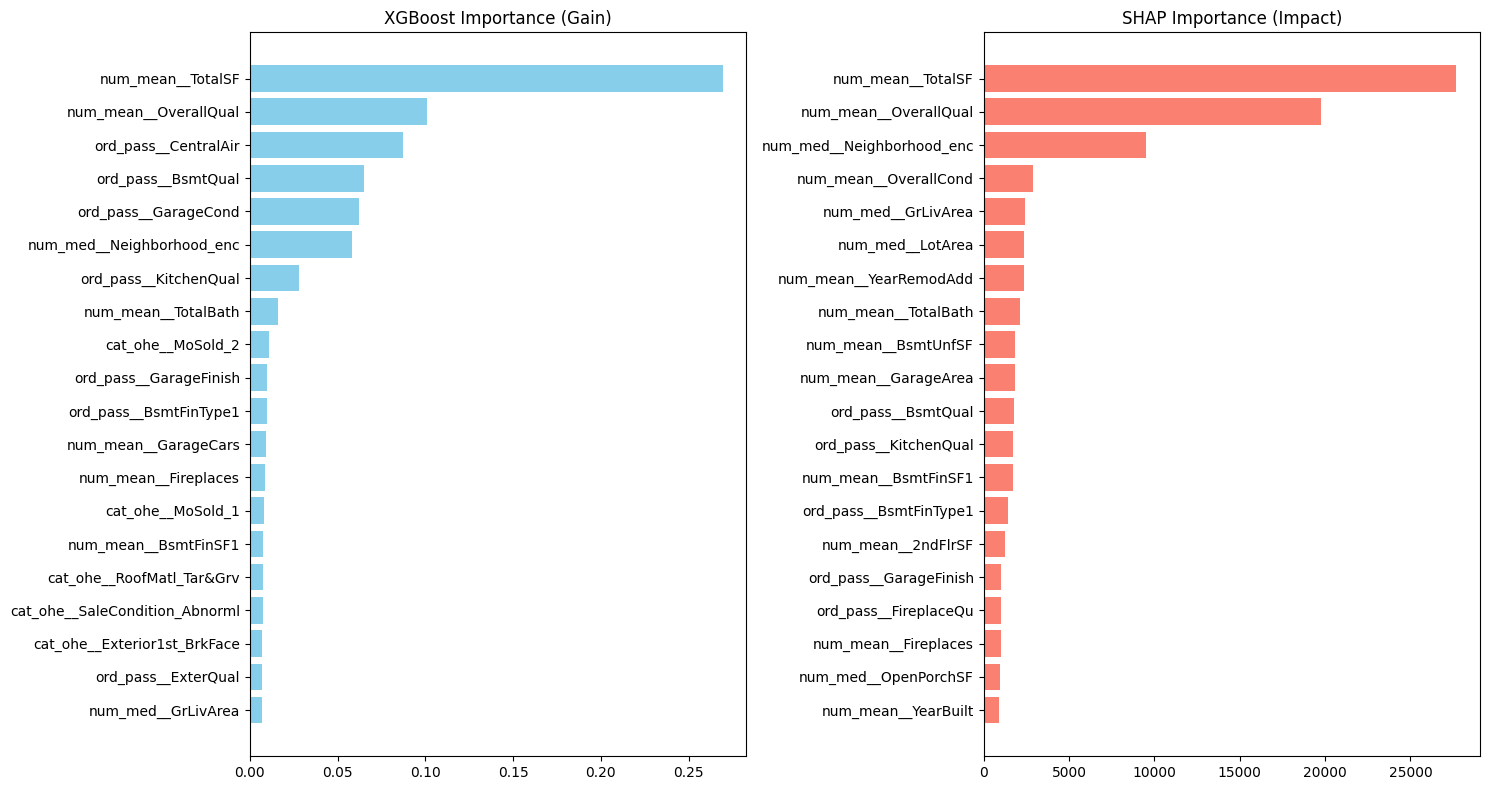

In [117]:
# 1. Get XGBoost Importance (Gain)
xgb_model = my_pipeline.named_steps['model']
feature_names = my_pipeline.named_steps['preprocessor'].get_feature_names_out()
xgb_importances = xgb_model.feature_importances_
sorted_idx_xgb = xgb_importances.argsort()[-20:]

# 2. Get SHAP Importance (Mean Absolute SHAP Value)
# We take the mean of the absolute values to see overall magnitude
shap_importance = np.abs(shap_values).mean(0)
sorted_idx_shap = shap_importance.argsort()[-20:]

# 3. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 8))

# XGBoost Plot
ax1.barh(feature_names[sorted_idx_xgb], xgb_importances[sorted_idx_xgb], color='skyblue')
ax1.set_title("XGBoost Importance (Gain)")

# SHAP Plot 
ax2.barh(feature_names[sorted_idx_shap], shap_importance[sorted_idx_shap], color='salmon')
ax2.set_title("SHAP Importance (Impact)")

plt.tight_layout()
plt.show()

# 15. A Comparative Study of Irreducible Error

### Consistent Outliers Across Models

Both models retain the **same extreme outliers**, suggesting these houses (**IDs 633, 1299, 689, 770**) are intrinsically difficult to predict, regardless of feature engineering. 

Interestingly, the Engineered Model actually **reduced the Percent Error for three out of four** of these outliers, notably bringing **ID 633** down from a **138% error to 128%**. This suggests that the consolidated TotalSF feature provided a more accurate ceiling for these properties than the fragmented baseline features.

The table below shows percent errors and their change between models:

| Id   | Actual  | Predicted (Baseline) | Predicted (Engineered) | Percent Error Baseline | Percent Error Engineered | **Difference**     |
| ---- | ------- | -------------------- | ---------------------- | ---------------------- | ------------------------ | ------------------ |
| 633  | 82,500  | 197,080              | 188,117                | 138.9%                 | 128.0%                   | **-10.87% Better** |
| 1299 | 160,000 | 261,217              | 251,324                | 63.3%                  | 57.1%                    | **-6.19% Better**  |
| 689  | 392,000 | 244,607              | 242,704                | 37.6%                  | 38.1%                    | **+0.50% Worse**   |
| 770  | 538,000 | 413,590              | 446,849                | 23.1%                  | 16.9%                    | **-6.21% Better**  |

**Interpretation:**

Most **extreme errors improved** in the Engineered model, except for **ID 689**, which worsened marginally.

This confirms that **feature engineering improves overall model stability**, but some **rare or extreme cases remain inherently challenging**. The consistency of these outliers suggests that these data points represent **intrinsic noise, atypical market behavior, or non-standard transactions**, rather than flaws in the model’s architecture or logic.

In [120]:
import pandas as pd

# Create a summary dataframe to investigate
results_df = pd.DataFrame({
    'Actual': y_valid,
    'Predicted': predictions,
    'Error': y_valid - predictions,
    'Percent_Error': abs((y_valid - predictions) / y_valid) * 100
})

# Sort by the biggest errors (Absolute value)
nightmare_houses = results_df.sort_values(by='Percent_Error', ascending=False).head(20)
print(nightmare_houses)

      Actual      Predicted          Error  Percent_Error
Id                                                       
633    82500  188117.203125 -105617.203125     128.020852
1299  160000  251324.468750  -91324.468750      57.077793
689   392000  242704.093750  149295.906250      38.085690
1388  136000  184673.250000  -48673.250000      35.789154
309    82500  110086.546875  -27586.546875      33.438239
663   110000  146231.078125  -36231.078125      32.937344
590    79500  105392.734375  -25892.734375      32.569477
1164  108959  144025.281250  -35066.281250      32.183006
1123  112000   77196.984375   34803.015625      31.074121
439    90350  117522.703125  -27172.703125      30.074934
922   145900  188819.953125  -42919.953125      29.417377
667   129000  166196.250000  -37196.250000      28.834302
536   107500  137887.468750  -30387.468750      28.267413
480    89471  114110.304688  -24639.304688      27.538873
331   119000  151584.906250  -32584.906250      27.382274
530   200624  

In [122]:
# Get the extreme ends of the Error spectrum
# Provides a dollar-scale view of worst-case model deviations


top_negatives = results_df.nsmallest(2, 'Error') # Over-predicted (Negative Error)
top_positives = results_df.nlargest(2, 'Error')  # Under-predicted (Positive Error)

error_extremes = pd.concat([top_negatives, top_positives])
print('Extreme Error Table (Engineered Model):\n\n', error_extremes)

Extreme Error Table (Engineered Model):

       Actual      Predicted          Error  Percent_Error
Id                                                       
633    82500  188117.203125 -105617.203125     128.020852
1299  160000  251324.468750  -91324.468750      57.077793
689   392000  242704.093750  149295.906250      38.085690
770   538000  446849.406250   91150.593750      16.942490


# 16. Recommendation

Given that the outliers persisted across both model architectures, further performance gains likely require a shift in strategy rather than incremental feature expansion. The following directions are recommended:

**Normalize the Target Distribution**: The current wide range of house prices makes it difficult for a single model to maintain consistent percentage accuracy. Future work should address the skew in the price data to ensure low-value homes are not disproportionately penalized by the evaluation metrics.

**Explore Segmented Modeling**: Instead of a single "catch-all" model, grouping houses by price range (e.g., Entry-level vs. Luxury) would allow the algorithm to learn the specific price logic of different market segments. This would prevent the model from over-relying on general trends when encountering unique or "distressed" properties.

**Prioritize Parsimony (Simplicity)**: Attempt 2 demonstrated that increasing feature complexity does not guarantee higher accuracy. Future efforts should prioritize "high-signal" features that address specific error patterns, such as the over-estimation of lower-valued homes, rather than broad feature addition.

These directions represent the logical next step in moving beyond simple feature addition.



# 17. Final Conclusion

This project followed an iterative data science lifecycle, beginning with a robust baseline and progressing through feature experimentation and deep diagnostic analysis.

**Key Insights**:

**Feature Evolution**: Through feature engineering, I successfully consolidated multiple features, e.g, area-based metrics into a singular **TotalSF** feature. While these increased the model's stability (**reducing Cross-Validation variance by 4%**), this increased robustness came at the cost of a higher Mean Absolute Error ($+1,125$). This highlights a classic trade-off in machine learning between abstraction (stability) and granularity (precision).

**The Noise Floor (Irreducible Error)**: The persistence of the four "Nightmare" outliers (**IDs 633, 1299, 689, 770**) across both model versions suggests that these properties represent stochastic noise or non-market conditions that fall outside the predictive reach of the available data.


This study confirms that while feature engineering can significantly streamline model logic and improve reliability, the "cleanest" model is not always the highest-scoring one. The Baseline Model provided superior precision by maintaining granularity that the engineered features abstracted away. This underscores a key takeaway: simplifying a model’s architecture through **feature consolidation can improve stability**, but **may sacrifice the fine-grained detail necessary for peak predictive performance**.
